In [1]:
import os
import sys
import importlib
import scipy.io as sio

import numpy as np
import matplotlib.pyplot as plot
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
import src.band_segmentation as band_segmentation
importlib.reload(band_segmentation)
from src.band_segmentation import get_band_corr_groups

In [2]:
def load_data(name):
    data_path = os.path.join("..", "data")
    files = {
        "IP": ("Indian_pines.mat", "indian_pines_corrected", "Indian_pines_gt.mat", "indian_pines_gt"),
        "PU": ("PaviaU.mat", "paviaU", "PaviaU_gt.mat", "paviaU_gt"),
        "SA": ("Salinas.mat", "salinas", "Salinas_gt.mat", "salinas_gt"),
    }
    df, dk, gf, gk = files[name]
    data = sio.loadmat(os.path.join(data_path, df))[dk]
    labels = sio.loadmat(os.path.join(data_path, gf))[gk]
    return data, labels

In [82]:
dataset = "SA"  # IP | PU | SA

X, y = load_data(dataset)

Tier 0 (low): no bands
Tier 1 (lower_mid): 34 bands
Tier 2 (mid): 39 bands
Tier 3 (high): 127 bands


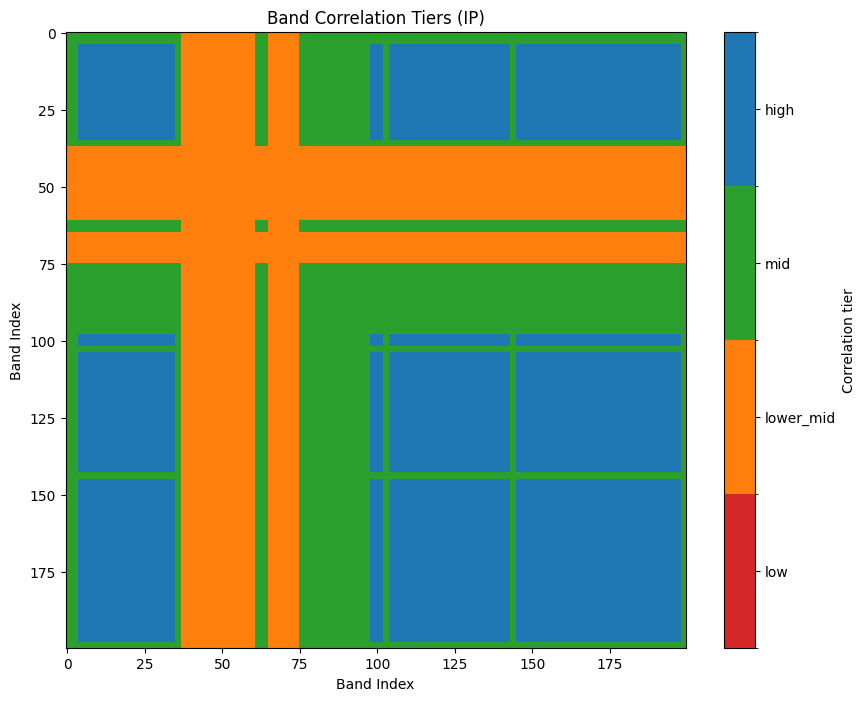

Tier 0 (low): no bands
Tier 1 (lower_mid): no bands
Tier 2 (mid): 27 bands
Tier 3 (high): 76 bands


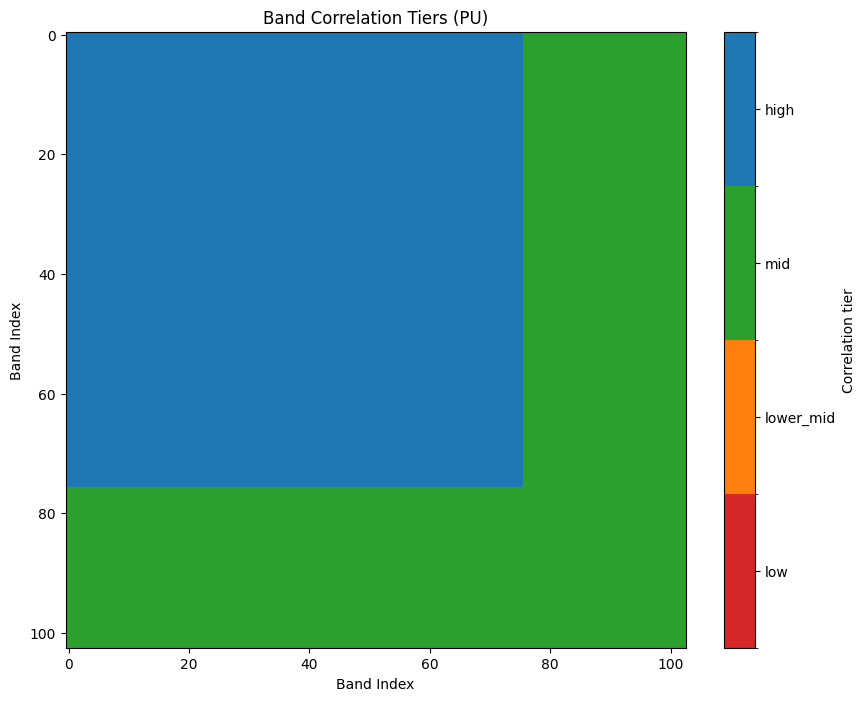

Tier 0 (low): no bands
Tier 1 (lower_mid): 21 bands
Tier 2 (mid): 129 bands
Tier 3 (high): 74 bands


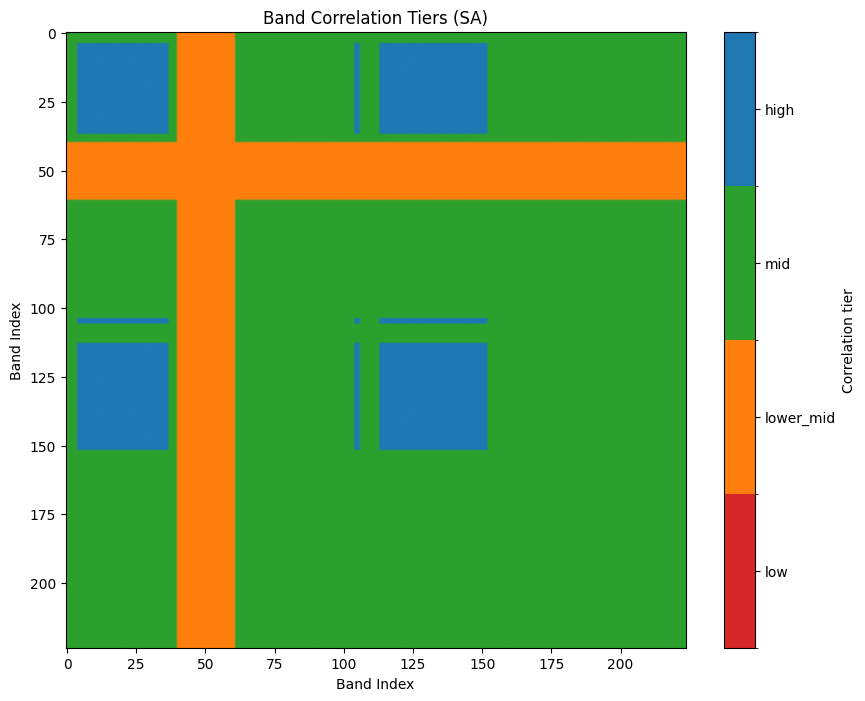

In [4]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

tier_names = ["low", "lower_mid", "mid", "high"]
tier_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
for dataset in ["IP", "PU", "SA"]:
    X, y = load_data(dataset)

    corr_groups = get_band_corr_groups(X)
    for tier, bands in enumerate(corr_groups):
        label = tier_names[tier]
        if bands.size == 0:
            print(f"Tier {tier} ({label}): no bands")
        else:
            print(f"Tier {tier} ({label}): {bands.size} bands")

    n_bands = X.shape[2]
    band_tier = np.full(n_bands, np.nan)
    for tier, bands in enumerate(corr_groups):
        if bands.size:
            band_tier[bands] = tier

    # (i, j) cell uses the lower tier of band i and band j (symmetric, 4 modes only)
    tier_grid = np.minimum(band_tier[:, None], band_tier[None, :])

    tier_cmap = ListedColormap(tier_colors)
    tier_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], tier_cmap.N)

    plot.figure(figsize=(10, 8))
    im = plot.imshow(tier_grid, cmap=tier_cmap, norm=tier_norm, aspect="auto")
    cbar = plot.colorbar(im, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(tier_names)
    cbar.set_label("Correlation tier")
    plot.title(f"Band Correlation Tiers ({dataset})")
    plot.xlabel("Band Index")
    plot.ylabel("Band Index")
    plot.show()